In [47]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_csv('NGAsub_flatfile_filtered.csv')
df.shape

(8907, 227)

In [22]:
df.columns

Index(['NGAsubRSN', 'DatabaseRegion', 'NGAsubEQID', 'NGAsubSSN',
       'Earthquake_Name', 'YEAR', 'MODY', 'HRMN', 'Earthquake_Magnitude',
       'Hypocenter_Latitude_deg',
       ...
       'T8pt500S', 'T9pt000S', 'T9pt500S', 'T10pt000S', 'T11pt000S',
       'T12pt000S', 'T13pt000S', 'T14pt000S', 'T15pt000S', 'T20pt000S'],
      dtype='object', length=227)

In [23]:
print("\n===== GLOBAL RANGES =====")

print("Mw range:", df['Earthquake_Magnitude'].min(), "-", df['Earthquake_Magnitude'].max())
print("RJB range:", df['Rjb_km'].min(), "-", df['Rjb_km'].max())
print("ZTOR range:", df['Ztor_km'].min(), "-", df['Ztor_km'].max())
print("Vs30 range:", df['Vs30_Selected_for_Analysis_m_s'].min(), "-", df['Vs30_Selected_for_Analysis_m_s'].max())


===== GLOBAL RANGES =====
Mw range: 4.1 - 9.12
RJB range: 0.0 - 999.0898298
ZTOR range: 0.0 - 186.004
Vs30 range: 94.7 - 2229.8


In [24]:
interface = df[df['Intra_Inter_Flag'] == 0]
intraslab = df[df['Intra_Inter_Flag'].isin([1,5])]

print("\n===== INTERFACE STATS =====")
print("Mw:", interface['Earthquake_Magnitude'].min(), "-", interface['Earthquake_Magnitude'].max())
print("ZTOR:", interface['Ztor_km'].min(), "-", interface['Ztor_km'].max())

print("\n===== INTRASLAB STATS =====")
print("Mw:", intraslab['Earthquake_Magnitude'].min(), "-", intraslab['Earthquake_Magnitude'].max())
print("ZTOR:", intraslab['Ztor_km'].min(), "-", intraslab['Ztor_km'].max())


===== INTERFACE STATS =====
Mw: 4.7 - 9.12
ZTOR: 0.0 - 36.011

===== INTRASLAB STATS =====
Mw: 4.1 - 8.28
ZTOR: 17.5 - 186.004


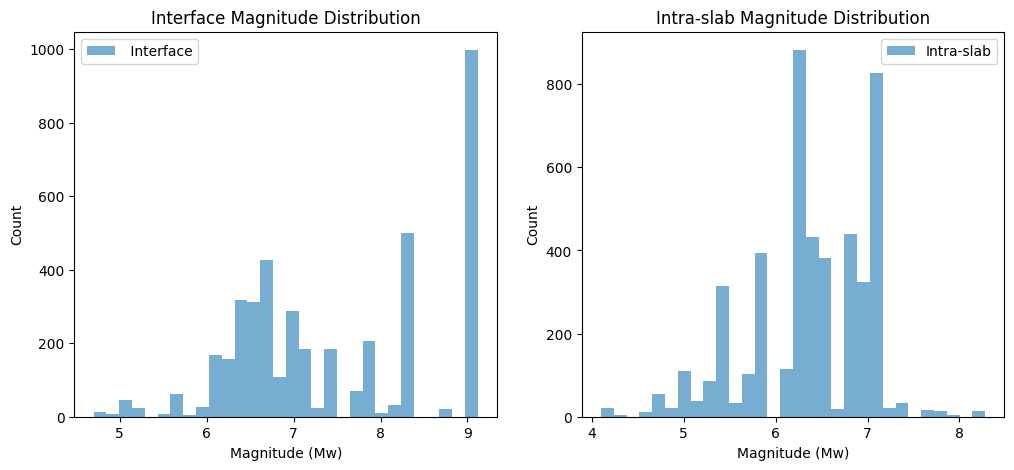

In [25]:
import matplotlib.pyplot as plt
#two separate histograms for interface and intraslab earthquakes side by side

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.hist(interface['Earthquake_Magnitude'], bins=30, alpha=0.6, label=' Interface')
plt.xlabel("Magnitude (Mw)")
plt.ylabel("Count")
plt.title("Interface Magnitude Distribution")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(intraslab['Earthquake_Magnitude'], bins=30, alpha=0.6, label='Intra-slab')
plt.xlabel("Magnitude (Mw)")
plt.ylabel("Count")
plt.title("Intra-slab Magnitude Distribution")
plt.legend()

plt.show()

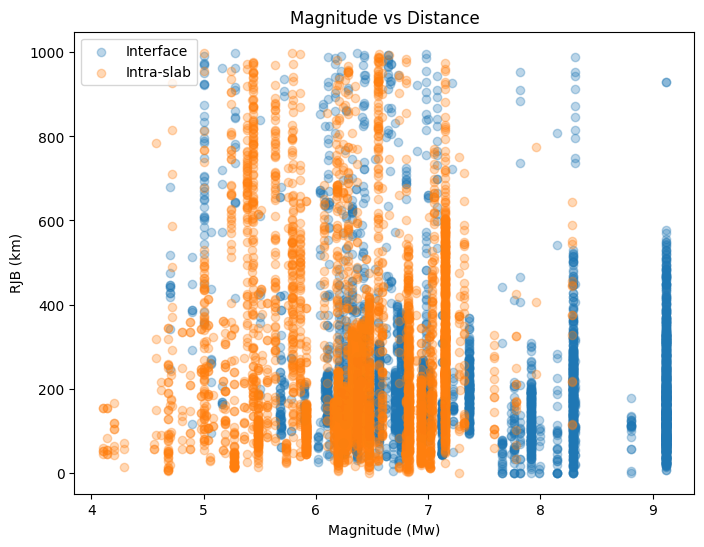

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(interface['Earthquake_Magnitude'], interface['Rjb_km'], alpha=0.3, label='Interface')
plt.scatter(intraslab['Earthquake_Magnitude'], intraslab['Rjb_km'], alpha=0.3, label='Intra-slab')

plt.xlabel("Magnitude (Mw)")
plt.ylabel("RJB (km)")
plt.title("Magnitude vs Distance")
plt.legend()
plt.show()


===== REGION DISTRIBUTION =====
DatabaseRegion
Japan                    0.616706
Taiwan                   0.140002
SouthAmerica             0.102167
Alaska                   0.086449
Cascadia                 0.042775
CentralAmerica&Mexico    0.011901
Name: proportion, dtype: float64


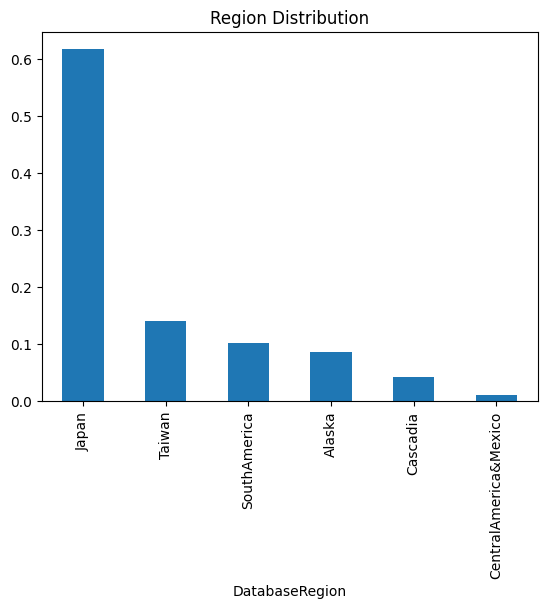

In [27]:
region_counts = df['DatabaseRegion'].value_counts(normalize=True)

print("\n===== REGION DISTRIBUTION =====")
print(region_counts)

region_counts.plot(kind='bar', title="Region Distribution")
plt.show()

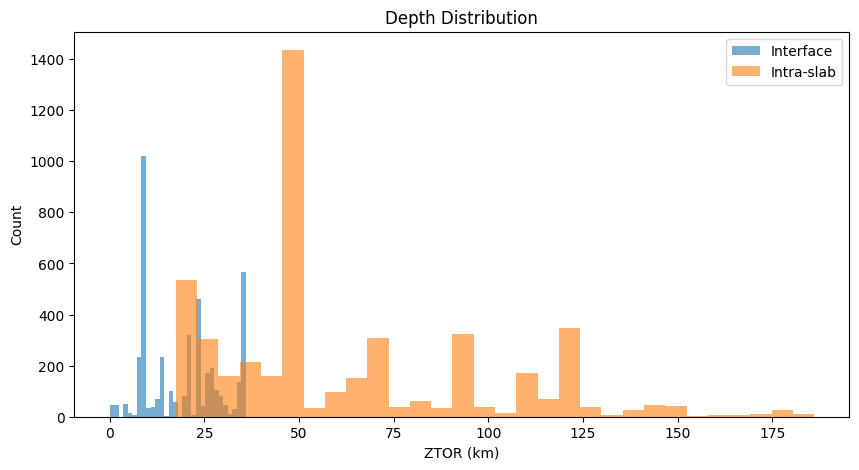

In [28]:
plt.figure(figsize=(10,5))

plt.hist(interface['Ztor_km'], bins=30, alpha=0.6, label='Interface')
plt.hist(intraslab['Ztor_km'], bins=30, alpha=0.6, label='Intra-slab')

plt.xlabel("ZTOR (km)")
plt.ylabel("Count")
plt.title("Depth Distribution")
plt.legend()
plt.show()

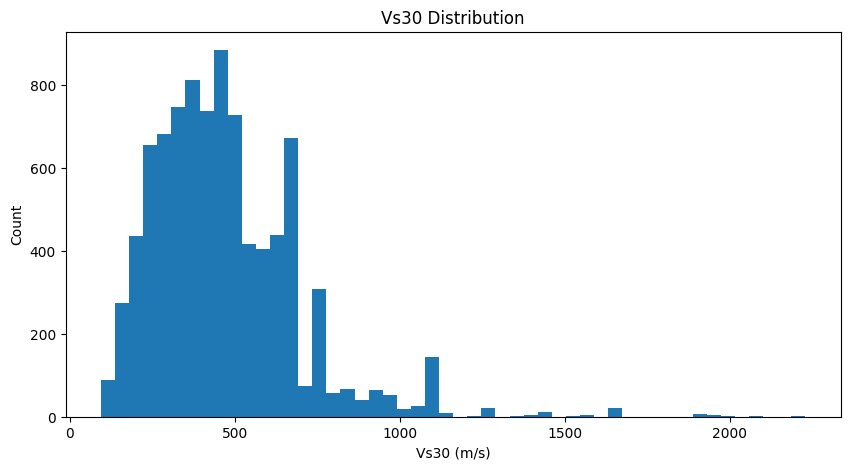

In [29]:
plt.figure(figsize=(10,5))

plt.hist(df['Vs30_Selected_for_Analysis_m_s'], bins=50)

plt.xlabel("Vs30 (m/s)")
plt.ylabel("Count")
plt.title("Vs30 Distribution")
plt.show()

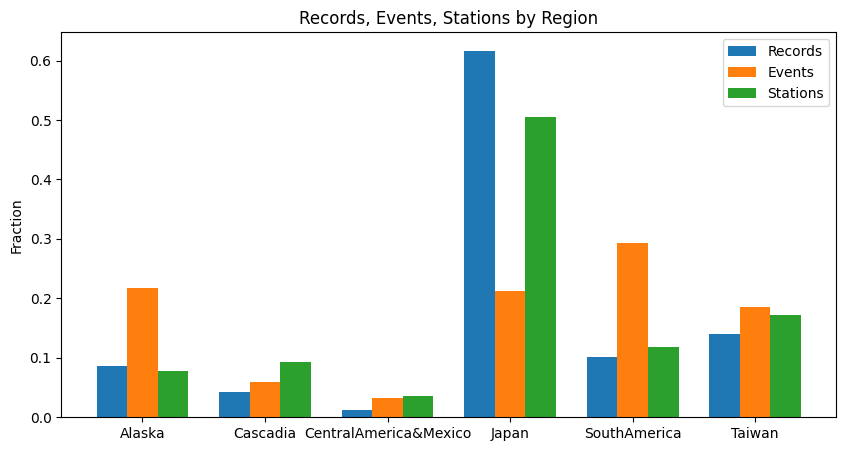

In [30]:
import matplotlib.pyplot as plt
import numpy as np

regions = df['DatabaseRegion'].unique()

records = []
events = []
stations = []

for r in regions:
    sub = df[df['DatabaseRegion'] == r]
    
    records.append(len(sub))
    events.append(sub['NGAsubEQID'].nunique())
    stations.append(sub['NGAsubSSN'].nunique())

# Normalize (percentage like paper)
records = np.array(records) / sum(records)
events = np.array(events) / sum(events)
stations = np.array(stations) / sum(stations)

x = np.arange(len(regions))
w = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - w, records, width=w, label='Records')
plt.bar(x, events, width=w, label='Events')
plt.bar(x + w, stations, width=w, label='Stations')

plt.xticks(x, regions)
plt.ylabel("Fraction")
plt.title("Records, Events, Stations by Region")
plt.legend()
plt.show()

In [32]:
import pandas as pd

rows = []

for region in df['DatabaseRegion'].unique():
    for t, label in [(0, 'interface'), ([1,5], 'intraslab')]:
        
        if isinstance(t, list):
            sub = df[(df['DatabaseRegion']==region) & (df['Intra_Inter_Flag'].isin(t))]
        else:
            sub = df[(df['DatabaseRegion']==region) & (df['Intra_Inter_Flag']==t)]
        
        if len(sub) == 0:
            continue
        
        rows.append({
            'Region': f"{region} ({label})",
            'Mw_min': sub['Earthquake_Magnitude'].min(),
            'Mw_max': sub['Earthquake_Magnitude'].max(),
            'RJB_min': sub['Rjb_km'].min(),
            'RJB_max': sub['Rjb_km'].max(),
            'ZTOR_min': sub['Ztor_km'].min(),
            'ZTOR_max': sub['Ztor_km'].max(),
            'Vs30_min': sub['Vs30_Selected_for_Analysis_m_s'].min(),
            'Vs30_max': sub['Vs30_Selected_for_Analysis_m_s'].max(),
        })

table1 = pd.DataFrame(rows)
#save table as csv
table1.to_csv("table1.csv", index=False)
table1



,Region,Mw_min,Mw_max,RJB_min,RJB_max,ZTOR_min,ZTOR_max,Vs30_min,Vs30_max
0,Alaska (interface),5.00,7.21,39.497503,999.089830,9.915,32.8780,322.0000,750.0000
1,Alaska (intraslab),5.00,7.96,28.104562,998.543383,34.548,154.5850,210.0000,750.0000
2,Cascadia (interface),4.70,4.90,114.838490,678.742760,12.279,17.9080,376.0000,665.0000
3,Cascadia (intraslab),4.58,6.80,3.516953,988.130997,18.000,52.1700,140.0000,2000.0000
4,CentralAmerica&Mexico (interface),6.32,7.99,0.000000,747.248922,6.000,29.8100,225.0000,586.0000
5,CentralAmerica&Mexico (intraslab),6.47,7.32,107.649692,945.524102,36.430,158.5660,281.0000,2100.0000
6,Japan (interface),5.89,9.12,0.000000,928.831581,1.220,36.0110,94.7000,2229.8000
7,Japan (intraslab),5.48,8.28,0.000000,644.875826,17.500,120.3534,94.7000,1909.1000
8,SouthAmerica (interface),6.10,8.81,0.000000,995.043964,0.000,33.9730,198.0000,1951.0000
9,SouthAmerica (intraslab),6.07,7.78,0.000000,995.105645,33.280,186.0040,116.0000,1639.0000


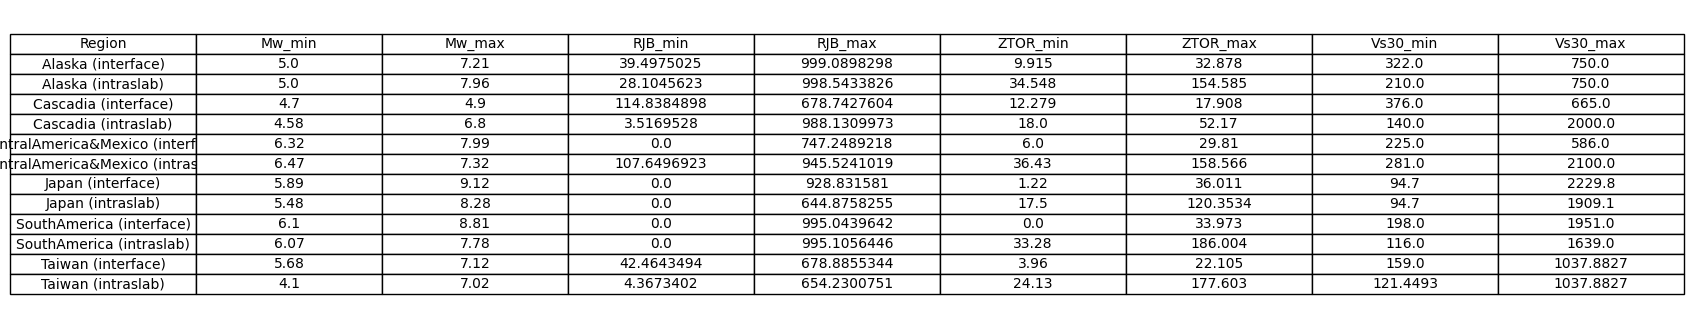

In [34]:
# save as image table
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 4))
ax.axis('tight')
ax.axis('off')
the_table = ax.table(cellText=table1.values, colLabels=table1.columns, cellLoc = 'center', loc='center')
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 1.2)
plt.savefig("table1.png", bbox_inches='tight')

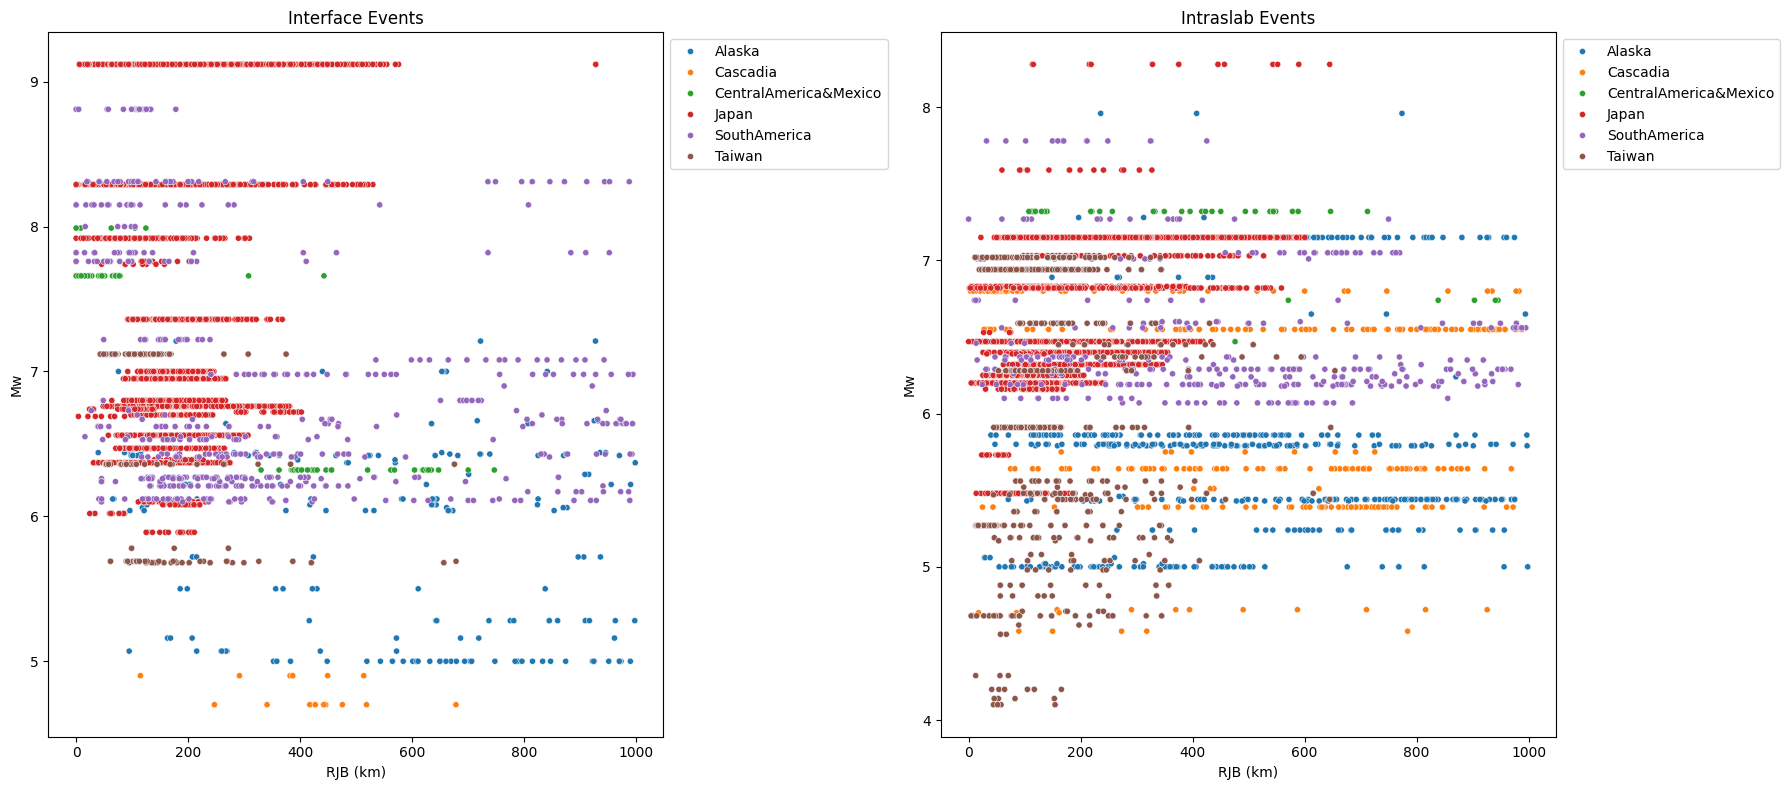

In [41]:
import seaborn as sns

interface = df[df['Intra_Inter_Flag'] == 0]
intraslab = df[df['Intra_Inter_Flag'].isin([1,5])]

plt.figure(figsize=(18,8))
# Interface
plt.subplot(1,2,1)
sns.scatterplot(
    data=interface,
    x='Rjb_km',
    y='Earthquake_Magnitude',
    hue='DatabaseRegion',
    s=20
)
plt.title("Interface Events")
plt.xlabel("RJB (km)")
plt.ylabel("Mw")
#put legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Intraslab
plt.subplot(1,2,2)
sns.scatterplot(
    data=intraslab,
    x='Rjb_km',
    y='Earthquake_Magnitude',
    hue='DatabaseRegion',
    s=20
)
plt.title("Intraslab Events")
plt.xlabel("RJB (km)")
plt.ylabel("Mw")
#put legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

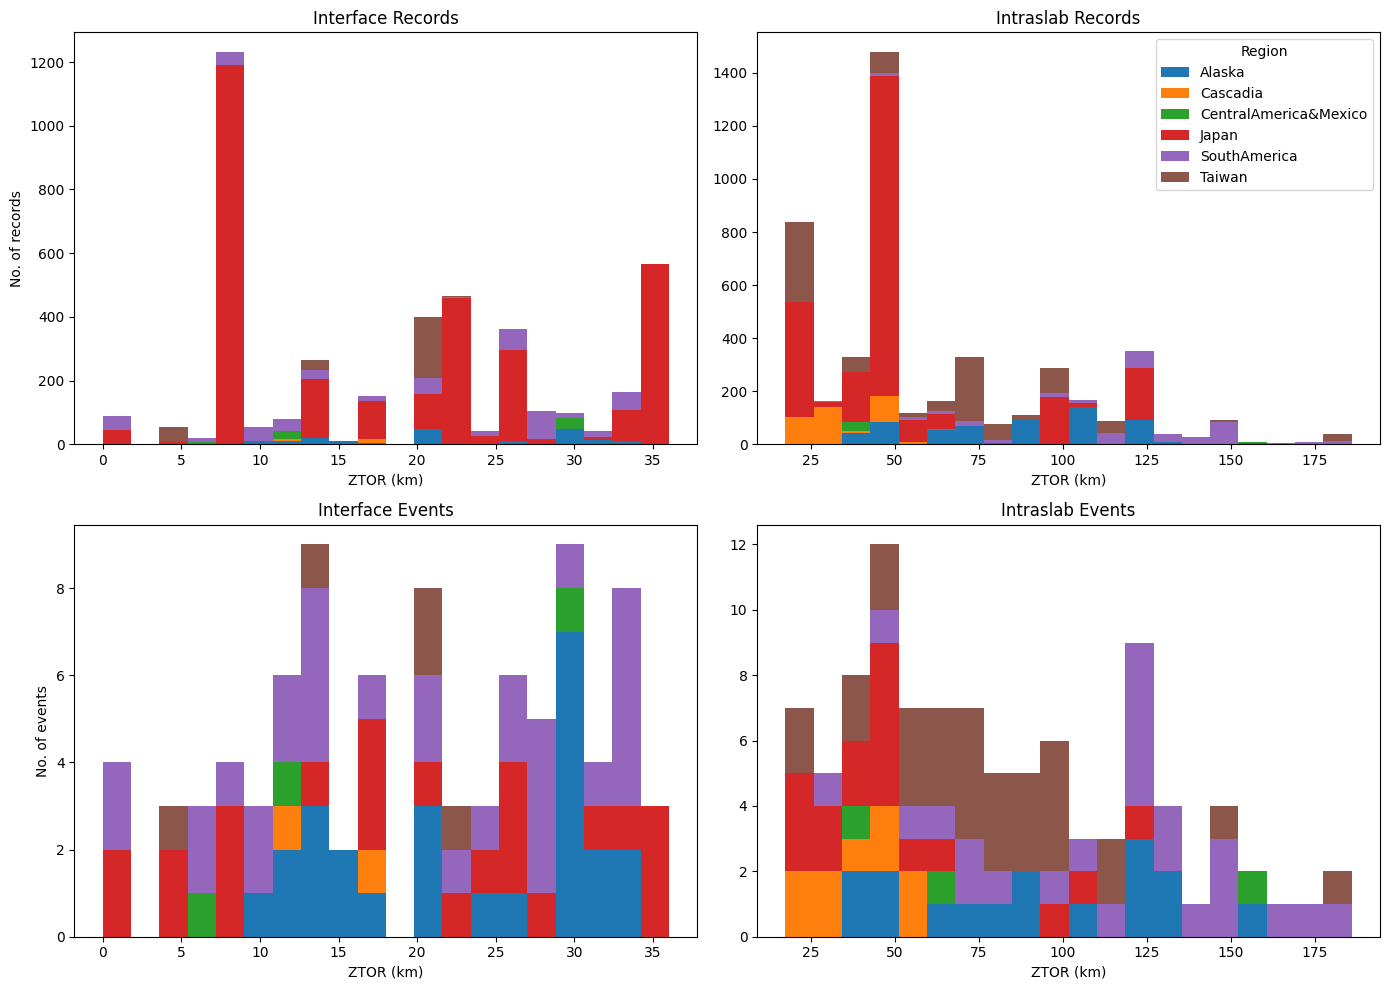

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Split data
interface = df[df['Intra_Inter_Flag'] == 0]
intraslab = df[df['Intra_Inter_Flag'].isin([1,5])]

regions = sorted(df['DatabaseRegion'].unique())

# Color map (fixed for consistency)
colors = plt.cm.tab10(range(len(regions)))

# -----------------------------
# HELPER FUNCTION
# -----------------------------
def get_region_data(data, col):
    return [data[data['DatabaseRegion']==r][col].values for r in regions]

def get_event_data(data, col):
    # unique event ZTOR (mean per event)
    event_vals = []
    for r in regions:
        sub = data[data['DatabaseRegion']==r]
        grouped = sub.groupby('NGAsubEQID')[col].mean()
        event_vals.append(grouped.values)
    return event_vals

# -----------------------------
# PLOTTING
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(14,10))

# ===== TOP LEFT: Interface Records =====
axs[0,0].hist(
    get_region_data(interface, 'Ztor_km'),
    bins=20,
    stacked=True,
    color=colors,
    label=regions
)
axs[0,0].set_title("Interface Records")
axs[0,0].set_xlabel("ZTOR (km)")
axs[0,0].set_ylabel("No. of records")

# ===== TOP RIGHT: Intraslab Records =====
axs[0,1].hist(
    get_region_data(intraslab, 'Ztor_km'),
    bins=20,
    stacked=True,
    color=colors,
    label=regions
)
axs[0,1].set_title("Intraslab Records")
axs[0,1].set_xlabel("ZTOR (km)")

# ===== BOTTOM LEFT: Interface Events =====
axs[1,0].hist(
    get_event_data(interface, 'Ztor_km'),
    bins=20,
    stacked=True,
    color=colors
)
axs[1,0].set_title("Interface Events")
axs[1,0].set_xlabel("ZTOR (km)")
axs[1,0].set_ylabel("No. of events")

# ===== BOTTOM RIGHT: Intraslab Events =====
axs[1,1].hist(
    get_event_data(intraslab, 'Ztor_km'),
    bins=20,
    stacked=True,
    color=colors
)
axs[1,1].set_title("Intraslab Events")
axs[1,1].set_xlabel("ZTOR (km)")

# Legend (only once)
axs[0,1].legend(title="Region")

plt.tight_layout()
plt.show()

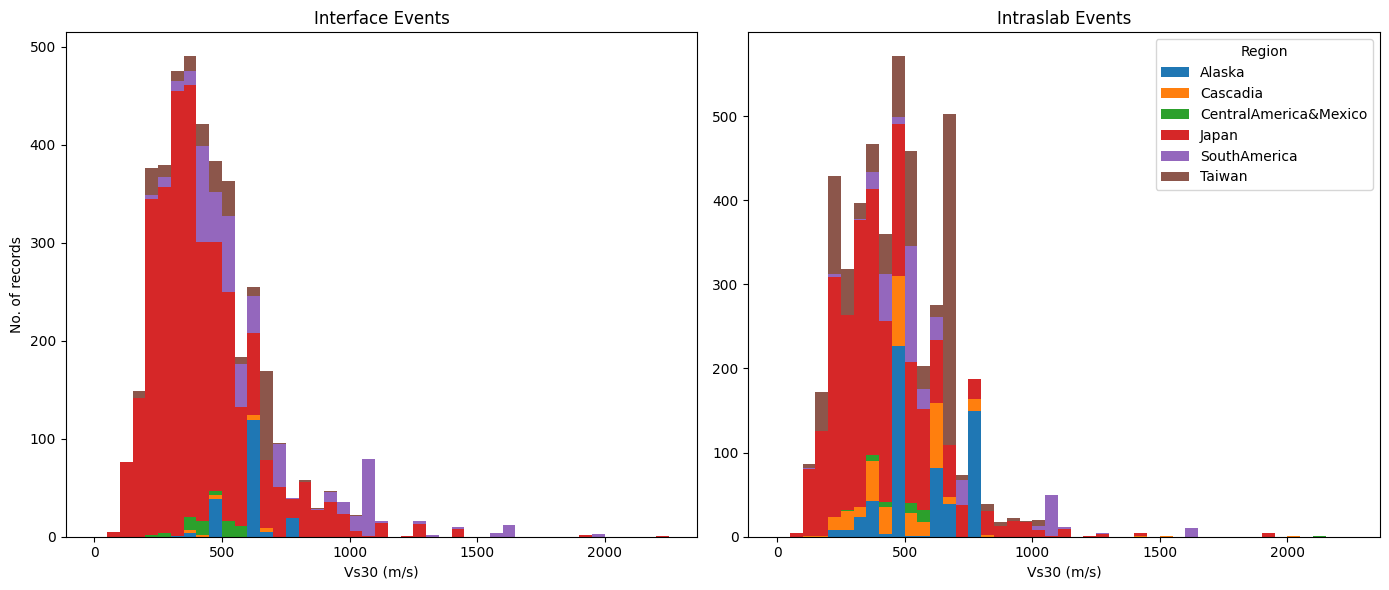

In [57]:
# Regions from data
regions = sorted(df['DatabaseRegion'].dropna().unique())

# Helper function
def get_region_data(data, col):
    out = []
    valid_regions = []
    
    for r in regions:
        vals = data[data['DatabaseRegion'] == r][col].dropna().values
        if len(vals) > 0:
            out.append(vals)
            valid_regions.append(r)
    
    return out, valid_regions

# Plot
fig, axs = plt.subplots(1, 2, figsize=(14,6))

# INTERFACE
idata, iregions = get_region_data(interface, 'Vs30_Selected_for_Analysis_m_s')

axs[0].hist(
    idata,
    bins=np.arange(0, 2300, 50),
    stacked=True,
    color=plt.cm.tab10(range(len(idata))),
    label=iregions
)

axs[0].set_title("Interface Events")
axs[0].set_xlabel("Vs30 (m/s)")
axs[0].set_ylabel("No. of records")

# INTRASLAB
sdata, sregions = get_region_data(intraslab, 'Vs30_Selected_for_Analysis_m_s')

axs[1].hist(
    sdata,
    bins=np.arange(0, 2300, 50),
    stacked=True,
    color=plt.cm.tab10(range(len(sdata))),
    label=sregions
)

axs[1].set_title("Intraslab Events")
axs[1].set_xlabel("Vs30 (m/s)")
axs[1].legend(title="Region")

plt.tight_layout()
plt.show()